In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

physician_fee_schedules = {}

base_path = "../../Data/Reimbursement_CPT_Codes"

columns_to_keep = ["HCPCS Code", "Work RVU"]

for year in range(2000, 2026):
    file_path = f"{base_path}/{year}.csv"
    df = pd.read_csv(file_path)
    df = df.loc[:, df.columns.intersection(columns_to_keep)].copy()
    df["Year"] = year
    physician_fee_schedules[year] = df

combined_df = pd.concat(physician_fee_schedules.values(), ignore_index=True)

combined_df = combined_df[["Year", "HCPCS Code", "Work RVU"]]

inflation_path = "../../Data/Inflation_Table/inflation_table.csv"
inflation_df = pd.read_csv(inflation_path)

combined_df = combined_df.merge(inflation_df, on="Year", how="left")

combined_df["Work RVU"] = pd.to_numeric(combined_df["Work RVU"], errors="coerce")


In [2]:
grouping_path = "../../Supplementary_Tables/ST1/ST1.csv"
grouping_df = pd.read_csv(grouping_path)

combined_df["HCPCS Code"] = combined_df["HCPCS Code"].astype(str)
grouping_df["CPT Code"] = grouping_df["CPT Code"].astype(str)

combined_df = combined_df.merge(
    grouping_df[["CPT Code", "Group Name", "Group Number"]],
    left_on="HCPCS Code",
    right_on="CPT Code",
    how="left"
)

combined_df = combined_df.drop(columns=["CPT Code"])

grouped_df = (
    combined_df
    .groupby(["Year", "Group Name"], as_index=False)
    .mean(numeric_only=True)
)

work_rvu = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Work RVU"
).sort_index(axis=1)

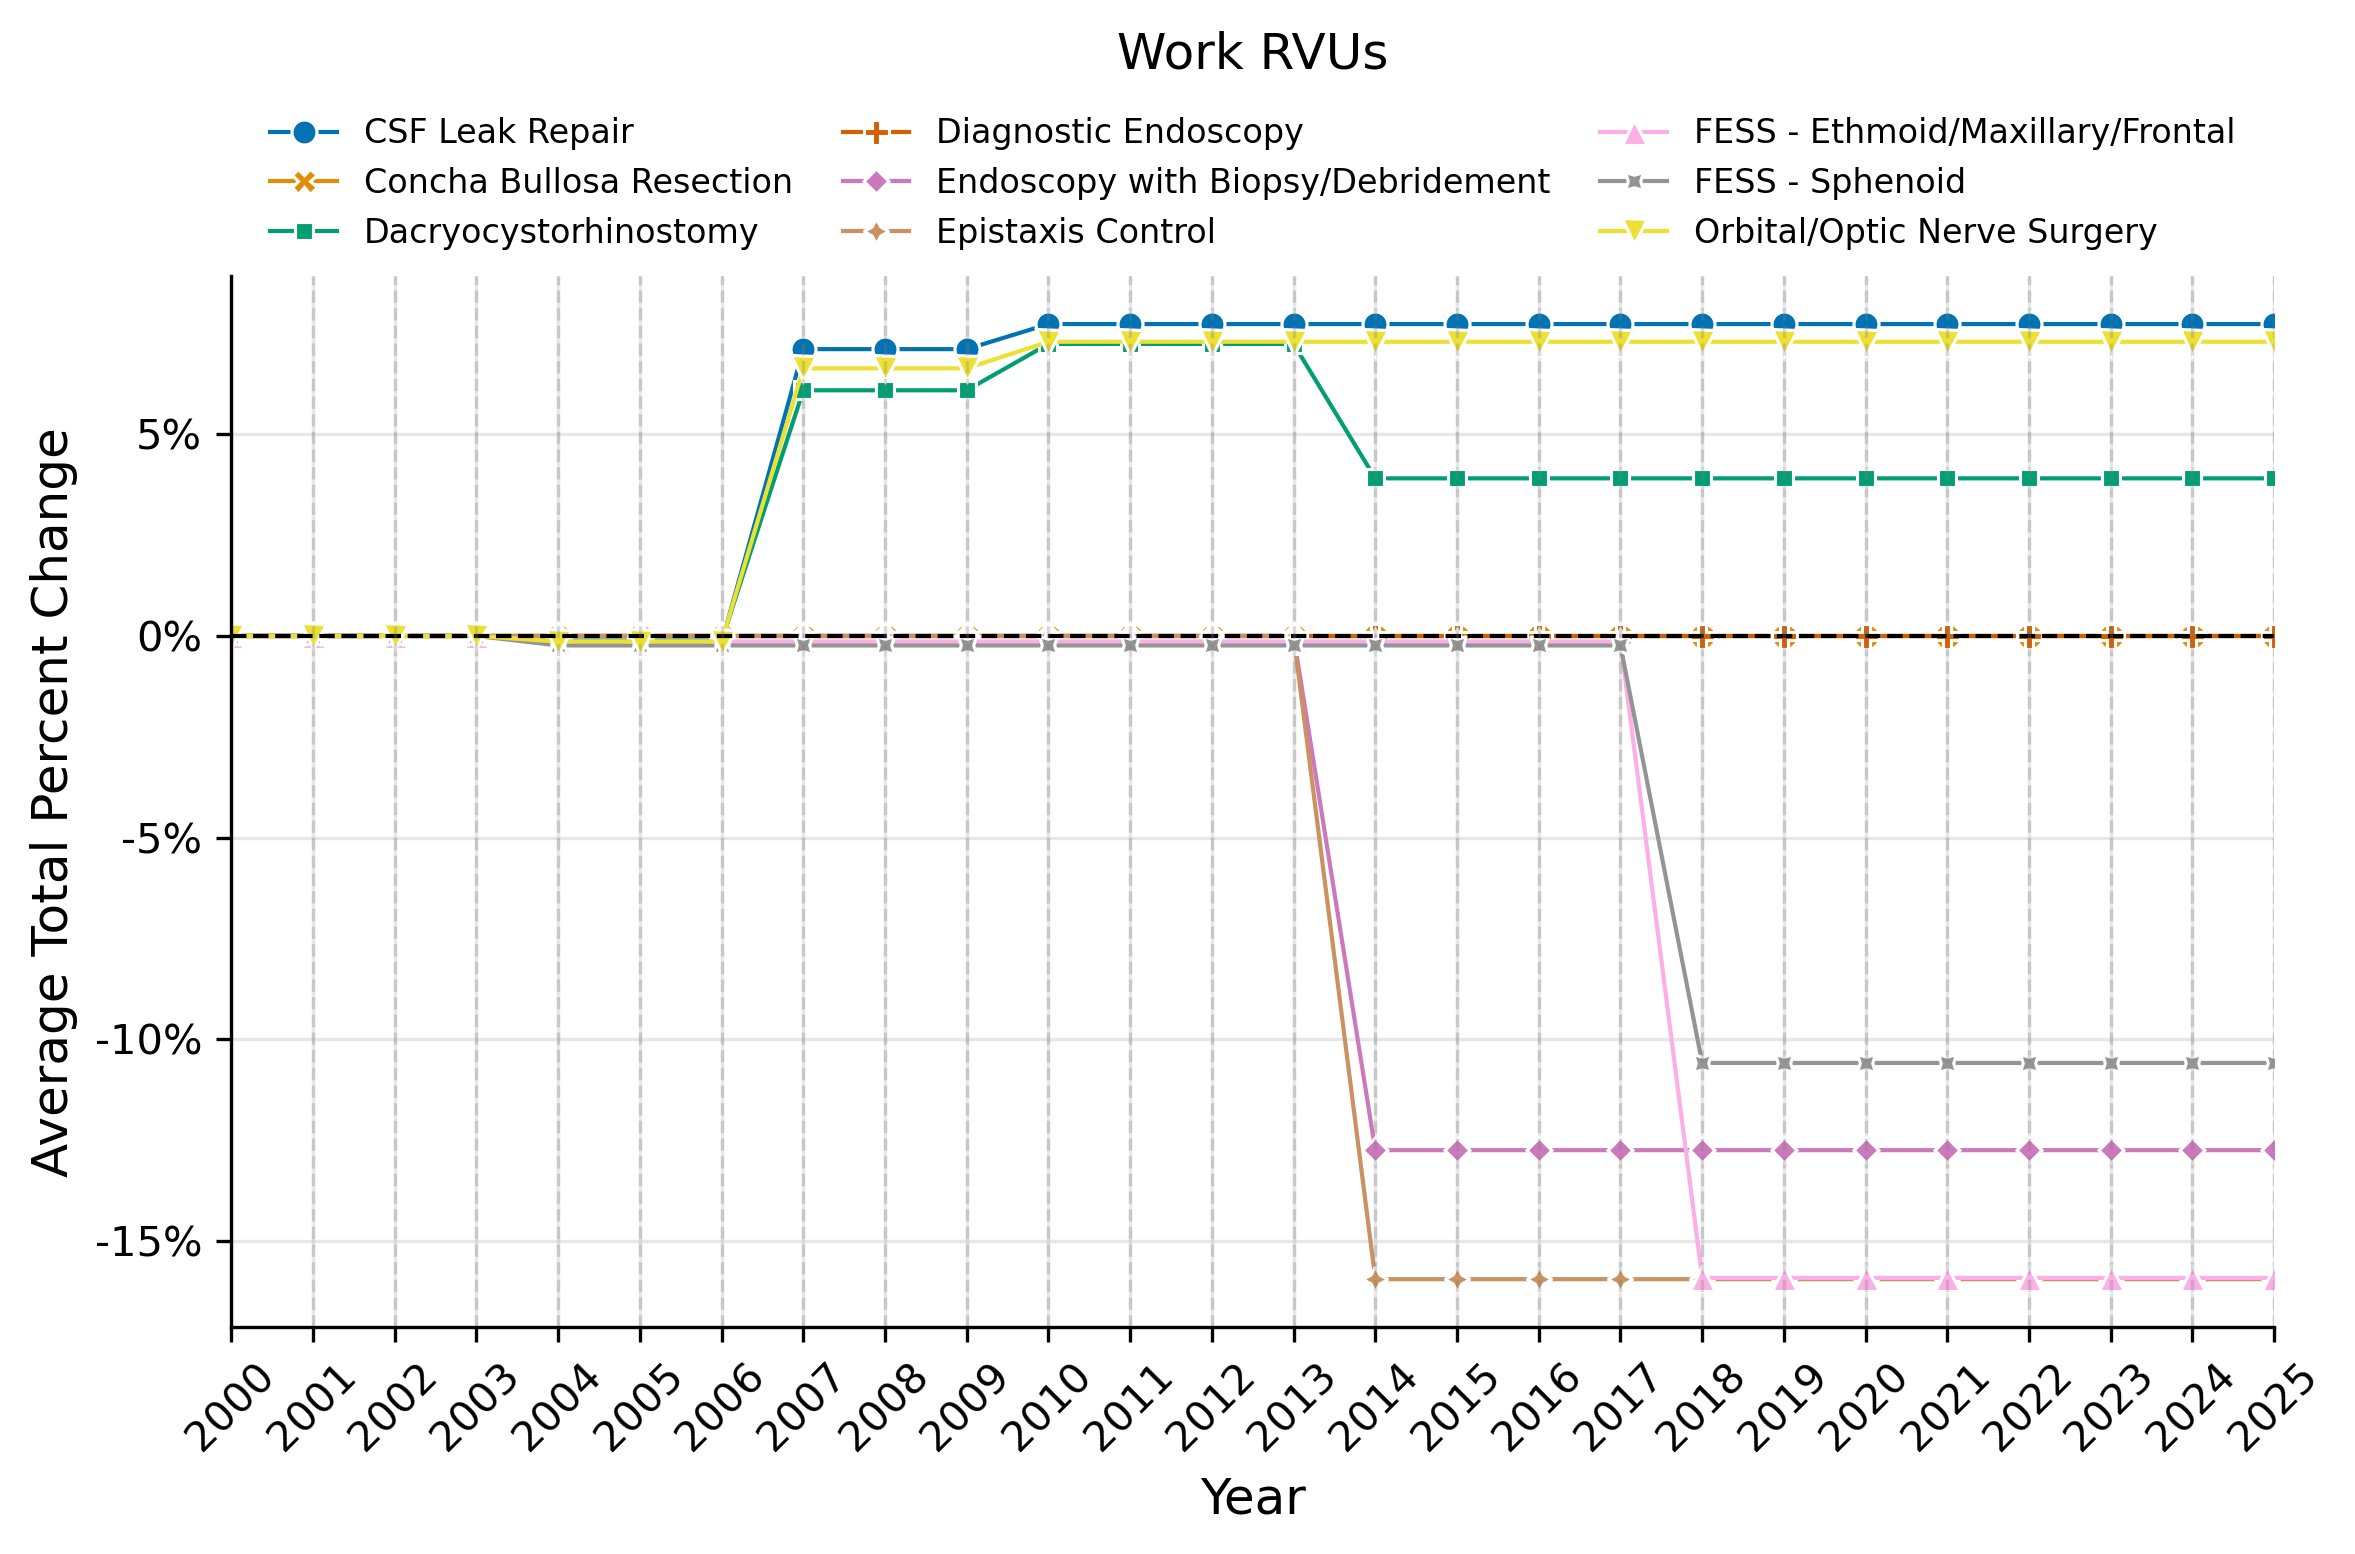

In [3]:
baseline_year = 2000

work_rvu_change = (
    work_rvu
    .subtract(work_rvu[baseline_year], axis=0)
    .divide(work_rvu[baseline_year], axis=0)
    * 100
)

plot_df = (
    work_rvu_change
    .reset_index()
    .melt(
        id_vars="Group Name",
        var_name="Year",
        value_name="Percent Change"
    )
)

plot_df["Year"] = plot_df["Year"].astype(int)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.lineplot(
    data=plot_df,
    x="Year",
    y="Percent Change",
    hue="Group Name",
    markers=True,
    palette="colorblind",
    style="Group Name",
    dashes=False,
    markersize=6,
    linewidth=1,
    ax=ax
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Work RVUs", fontsize=12, pad=50)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Total Percent Change", fontsize=12)

ax.set_xlim(2000, 2025)
ax.set_xticks(range(2000, 2026))
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(mtick.MultipleLocator(5))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,                
    frameon=False,
    fontsize=8,
    handlelength=2.0,
    columnspacing=1.5
)

plt.grid(alpha=0.3)
for year in range(2000, 2026):
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('F2.pdf')
plt.show()

In [4]:
# Statistical comparison of Work RVUs, 2000 vs 2025, paired at the CPT-code level.
# Groups with a single CPT code (or identical change across all codes) have no
# within-group variation to test, so their p-values are reported as NaN.
import numpy as np
from scipy import stats

rvu_by_code = combined_df.pivot_table(
    index=["Group Name", "HCPCS Code"],
    columns="Year",
    values="Work RVU"
)[[2000, 2025]].dropna()

def paired_tests(v2000, v2025):
    diffs = v2025 - v2000
    if len(diffs) < 2 or np.allclose(diffs, diffs[0]):
        return np.nan, np.nan, np.nan
    t_stat, t_p = stats.ttest_rel(v2025, v2000)
    try:
        _, w_p = stats.wilcoxon(v2025, v2000)
    except ValueError:
        w_p = np.nan
    return t_stat, t_p, w_p

def summarize(label, v2000, v2025):
    t_stat, t_p, w_p = paired_tests(v2000, v2025)
    return {
        "Group Name": label,
        "n CPT Codes": len(v2000),
        "Mean Work RVU 2000": v2000.mean(),
        "Mean Work RVU 2025": v2025.mean(),
        "Percent Change": (v2025.mean() - v2000.mean()) / v2000.mean() * 100,
        "Paired t": t_stat,
        "p (paired t-test)": t_p,
        "p (Wilcoxon)": w_p,
    }

rows = [
    summarize(group, sub[2000].to_numpy(), sub[2025].to_numpy())
    for group, sub in rvu_by_code.groupby(level="Group Name")
]
rows.append(summarize("All CPT Codes", rvu_by_code[2000].to_numpy(), rvu_by_code[2025].to_numpy()))

stats_df = pd.DataFrame(rows).round(4)
stats_df

,Group Name,n CPT Codes,Mean Work RVU 2000,Mean Work RVU 2025,Percent Change,Paired t,p (paired t-test),p (Wilcoxon)
0,CSF Leak Repair,2,17.7150,19.0850,7.7336,NaN,NaN,NaN
1,Concha Bullosa Resection,1,2.6100,2.6100,0.0000,NaN,NaN,NaN
2,Dacryocystorhinostomy,1,8.7000,9.0400,3.9080,NaN,NaN,NaN
3,Diagnostic Endoscopy,3,1.9733,1.9733,0.0000,NaN,NaN,NaN
4,Endoscopy with Biopsy/Debridement,1,2.9800,2.6000,-12.7517,NaN,NaN,NaN
5,Epistaxis Control,1,3.2600,2.7400,-15.9509,NaN,NaN,NaN
6,FESS - Ethmoid/Maxillary/Frontal,5,5.8420,4.9120,-15.9192,-2.7219,0.0529,0.0625
7,FESS - Sphenoid,2,4.2500,3.8000,-10.5882,-15.0000,0.0424,0.5000
8,Orbital/Optic Nerve Surgery,3,16.6767,17.8933,7.2956,31.6495,0.0010,0.2500
9,All CPT Codes,19,7.7179,7.7326,0.1909,0.0686,0.9461,0.9547
